In [1]:
# EDA - ONS ASHE Salary Data
# checking median salary by occupation for 2021-2025
# need to unzip each year first before loading

import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

# checking what's inside the 2021 zip
with zipfile.ZipFile('ASHE_2021_13Jun2026.zip', 'r') as z:
    print("files inside 2021 zip:")
    print(z.namelist())

files inside 2021 zip:
['Occupation SOC20 (4) Table 14.10a   Paid hours worked - Basic 2021.xls', 'Occupation SOC20 (4) Table 14.10b   Paid hours worked - Basic 2021 CV.xls', 'Occupation SOC20 (4) Table 14.11a   Paid hours worked - Overtime 2021.xls', 'Occupation SOC20 (4) Table 14.11b   Paid hours worked - Overtime 2021 CV.xls', 'Occupation SOC20 (4) Table 14.12  Gender pay gap 2021.xls', 'Occupation SOC20 (4) Table 14.1a   Weekly pay - Gross 2021.xls', 'Occupation SOC20 (4) Table 14.1b   Weekly pay - Gross 2021 CV.xls', 'Occupation SOC20 (4) Table 14.2a   Weekly pay - Excluding overtime 2021.xls', 'Occupation SOC20 (4) Table 14.2b   Weekly pay - Excluding overtime 2021 CV.xls', 'Occupation SOC20 (4) Table 14.3a   Basic Pay - Including other pay 2021.xls', 'Occupation SOC20 (4) Table 14.3b   Basic Pay - Including other pay 2021 CV.xls', 'Occupation SOC20 (4) Table 14.4a   Overtime pay 2021.xls', 'Occupation SOC20 (4) Table 14.4b   Overtime pay 2021 CV.xls', 'Occupation SOC20 (4) Table

In [3]:
import subprocess
subprocess.run(['pip', 'install', 'xlrd'], capture_output=True)
print("xlrd installed!")

xlrd installed!


In [4]:
# loading the annual gross pay file directly from the zip - no need to extract!
year = 2021
filename = f'Occupation SOC20 (4) Table 14.7a   Annual pay - Gross {year}.xls'

with zipfile.ZipFile(f'ASHE_{year}_13Jun2026.zip', 'r') as z:
    with z.open(filename) as f:
        df_2021 = pd.read_excel(f, sheet_name=None)  # loading all sheets first

print("sheets in 2021 annual pay file:")
print(list(df_2021.keys()))

sheets in 2021 annual pay file:
['Notes', 'All', 'Male', 'Female', 'Full-Time', 'Part-Time', 'Male Full-Time', 'Male Part-Time', 'Female Full-Time', 'Female Part-Time']


In [5]:
# loading the 'All' sheet from the 2021 annual pay file
with zipfile.ZipFile('ASHE_2021_13Jun2026.zip', 'r') as z:
    with z.open(filename) as f:
        df_2021 = pd.read_excel(f, sheet_name='All', skiprows=4)

print("shape:", df_2021.shape)
print("\ncolumns:", df_2021.columns.tolist())
print("\nfirst 5 rows:")
print(df_2021.head())

shape: (558, 20)

columns: ['Description', 'Code', '(thousand)', 'Median', 'change', 'Mean', 'change.1', 10, 20, 25, 30, 40, 60, 70, 75, 80, 90, 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19']

first 5 rows:
                                Description    Code (thousand) Median  change  \
0                             All employees     NaN      23901  25990     NaN   
1  Managers, directors and senior officials     1.0       2611  40036     NaN   
2          Corporate managers and directors    11.0       2063  44234     NaN   
3     Chief Executives and Senior Officials   111.0        116  69794     NaN   
4     Chief executives and senior officials  1111.0        106  74273     NaN   

     Mean  change.1     10     20     25     30     40     60      70      75  \
0   31437       NaN   8788  14163  16733  18722  22210  30265   35567   38890   
1   53387       NaN  16884  23437  26237  28866  34000  46904   56253   62032   
2   58444       NaN  16975  24771  28193  30850  37500  52095   6

In [6]:
# cleaning up - keeping only the columns i need
df_2021_clean = df_2021[['Description', 'Code', 'Median']].copy()

# dropping rows with no SOC code or no median salary
df_2021_clean = df_2021_clean.dropna(subset=['Code'])
df_2021_clean['Median'] = pd.to_numeric(df_2021_clean['Median'], errors='coerce')
df_2021_clean = df_2021_clean.dropna(subset=['Median'])
df_2021_clean['Year'] = 2021

print("shape after cleaning:", df_2021_clean.shape)
print("\nfirst 10 rows:")
print(df_2021_clean.head(10))

shape after cleaning: (490, 4)

first 10 rows:
                                          Description    Code   Median  Year
1            Managers, directors and senior officials     1.0  40036.0  2021
2                    Corporate managers and directors    11.0  44234.0  2021
3               Chief Executives and Senior Officials   111.0  69794.0  2021
4               Chief executives and senior officials  1111.0  74273.0  2021
6                   Production Managers and Directors   112.0  41528.0  2021
7      Production managers and directors in manufa...  1121.0  40962.0  2021
8      Production managers and directors in constr...  1122.0  42599.0  2021
9      Production managers and directors in mining...  1123.0  45012.0  2021
10                  Functional Managers and Directors   113.0  53372.0  2021
11                   Financial managers and directors  1131.0  54986.0  2021


In [10]:
# loading all 5 years - each has slightly different filename
all_years = []

filenames = {
    2021: ('ASHE_2021_13Jun2026.zip', 'Occupation SOC20 (4) Table 14.7a   Annual pay - Gross 2021.xls'),
    2022: ('ASHE_2022_13Jun2026.zip', 'Occupation SOC20 (4) Table 14.7a   Annual pay - Gross 2022.xls'),
    2023: ('ASHE_2023_13Jun2026.zip', 'Occupation SOC20 (4) Table 14.7a   Annual pay - Gross 2023.xlsx'),
    2024: ('ASHE_2024_13Jun2026.zip', 'Occupation SOC20 (4) Table 14.7a   Annual pay - Gross 2024.xlsx'),
    2025: ('ASHE_2025_13Jun2026.zip', 'ashetable142025provisional/PROV - Occupation SOC20 (4) Table 14.7a   Annual pay - Gross 2025.xlsx'),
}

for year, (zipname, fname) in filenames.items():
    with zipfile.ZipFile(zipname, 'r') as z:
        with z.open(fname) as f:
            df_year = pd.read_excel(f, sheet_name='All', skiprows=4)
    
    df_year = df_year[['Description', 'Code', 'Median']].copy()
    df_year = df_year.dropna(subset=['Code'])
    df_year['Median'] = pd.to_numeric(df_year['Median'], errors='coerce')
    df_year = df_year.dropna(subset=['Median'])
    df_year['Year'] = year
    all_years.append(df_year)
    print(f"{year} loaded - {len(df_year)} occupations")

df_ashe = pd.concat(all_years, ignore_index=True)
print("\ntotal rows:", len(df_ashe))

2021 loaded - 490 occupations
2022 loaded - 458 occupations
2023 loaded - 483 occupations
2024 loaded - 496 occupations
2025 loaded - 498 occupations

total rows: 2425


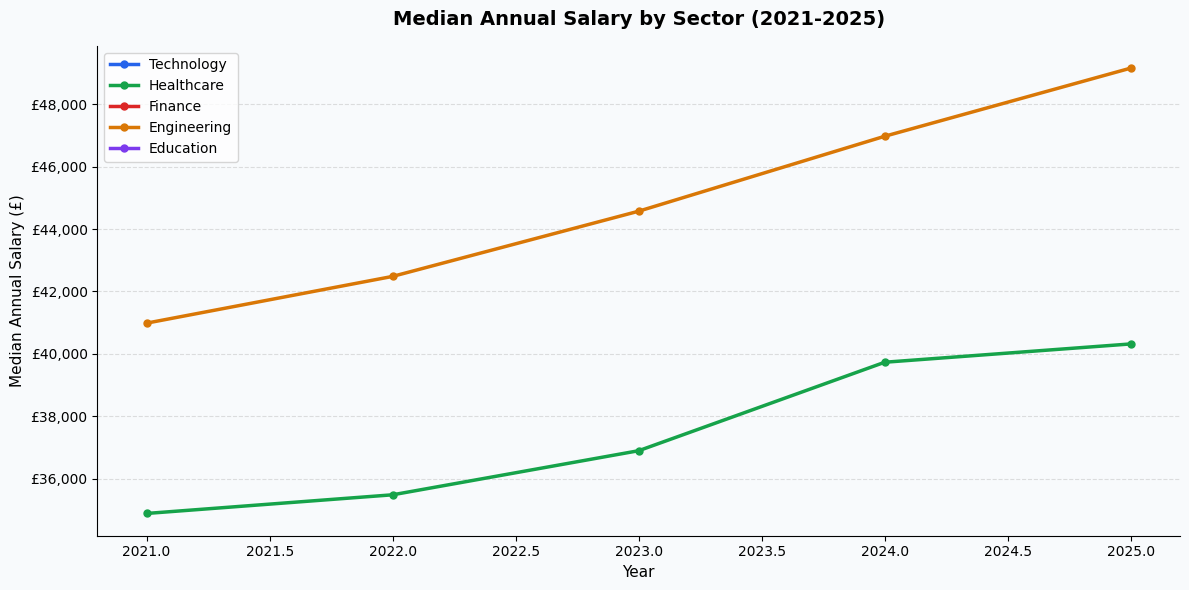

done!


In [11]:
# my 5 dissertation sectors - picking representative occupations
my_occupations = {
    'Technology': 'IT and telecommunications professionals',
    'Healthcare': 'Health professionals',
    'Finance': 'Business, finance and related associate professionals',
    'Engineering': 'Engineering professionals',
    'Education': 'Teaching and educational professionals'
}

# finding median salary trend for each sector
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f8fafc')
ax.set_facecolor('#f8fafc')

colors = ['#2563eb', '#16a34a', '#dc2626', '#d97706', '#7c3aed']

for (sector, keyword), color in zip(my_occupations.items(), colors):
    # filtering rows that match the keyword
    mask = df_ashe['Description'].str.contains(keyword, case=False, na=False)
    df_sector = df_ashe[mask].groupby('Year')['Median'].mean().reset_index()
    ax.plot(df_sector['Year'], df_sector['Median'],
            label=sector, color=color, linewidth=2.5, marker='o', markersize=5)

ax.set_title('Median Annual Salary by Sector (2021-2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Median Annual Salary (£)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('ashe_salary_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("done!")

In [13]:
# checking what descriptions are actually in the data
for keyword in ['IT', 'tech', 'finance', 'teach', 'education', 'engineer', 'health']:
    matches = df_ashe[df_ashe['Description'].str.contains(keyword, case=False, na=False)]['Description'].unique()
    print(f"\n'{keyword}' matches:")
    print(matches[:3])


'IT' matches:
['  Managers and Proprietors in Hospitality and Leisure Services'
 '   Social and humanities scientists' '   IT project managers']

'tech' matches:
['   Information technology directors'
 ' Science, research, engineering and technology professionals'
 '  Information Technology Professionals']

'finance' matches:
['  Finance Professionals'
 '   Finance and investment analysts and advisers'
 '  Finance Associate Professionals']

'teach' matches:
[' Teaching and other educational professionals'
 '  Teaching Professionals' '   Higher education teaching professionals']

'education' matches:
[' Teaching and other educational professionals'
 '   Higher education teaching professionals'
 '   Further education teaching professionals']

'engineer' matches:
[' Science, research, engineering and technology professionals'
 '  Engineering Professionals' '   Civil engineers']

'health' matches:
['  Health and Social Services Managers and Directors'
 '   Health services and public healt

Technology: 5 years found
Healthcare: 5 years found
Finance: 5 years found
Engineering: 5 years found
Education: 5 years found


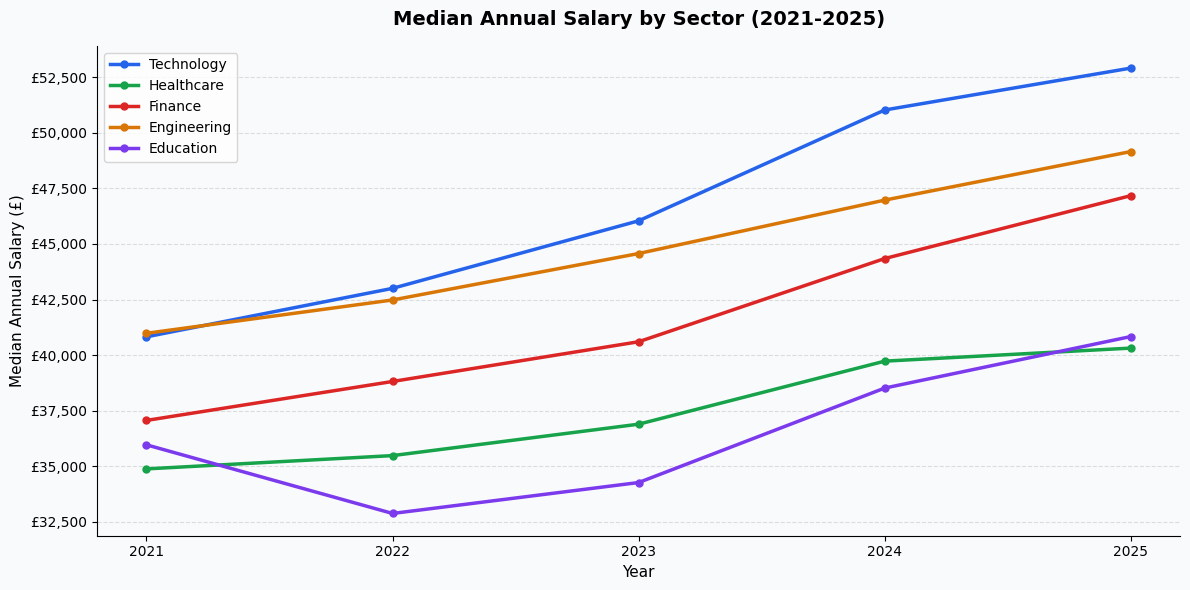

done!


In [14]:
# updated keywords based on what's actually in the data
my_occupations = {
    'Technology': 'Information Technology Professionals',
    'Healthcare': 'Health professionals',
    'Finance': 'Finance Professionals',
    'Engineering': 'Engineering Professionals',
    'Education': 'Teaching Professionals'
}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f8fafc')
ax.set_facecolor('#f8fafc')

colors = ['#2563eb', '#16a34a', '#dc2626', '#d97706', '#7c3aed']

for (sector, keyword), color in zip(my_occupations.items(), colors):
    mask = df_ashe['Description'].str.contains(keyword, case=False, na=False)
    df_sector = df_ashe[mask].groupby('Year')['Median'].mean().reset_index()
    print(f"{sector}: {len(df_sector)} years found")
    ax.plot(df_sector['Year'], df_sector['Median'],
            label=sector, color=color, linewidth=2.5, marker='o', markersize=5)

ax.set_title('Median Annual Salary by Sector (2021-2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Median Annual Salary (£)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_xticks([2021, 2022, 2023, 2024, 2025])
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('ashe_salary_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("done!")

In [15]:
# notes for sprint 2
print("key findings from ASHE EDA:")
print("- 5 years loaded: 2021-2025")
print("- total rows:", len(df_ashe))
print("- median salary data by SOC 2020 occupation codes")
print("- 2025 file is provisional - flag this in the dissertation")
print("- suppressed cells (x) already handled by coerce in to_numeric")

key findings from ASHE EDA:
- 5 years loaded: 2021-2025
- total rows: 2425
- median salary data by SOC 2020 occupation codes
- 2025 file is provisional - flag this in the dissertation
- suppressed cells (x) already handled by coerce in to_numeric
